# Notebook 2 - Neural Network Basics with NumPy

This notebook is a compact introduction to a **small neural network**, written from scratch in NumPy.

It mirrors a simple linear-model tutorial, but uses a model that can learn a **nonlinear decision boundary**.

## Goals
By the end of this notebook, we should be able to:
- build a synthetic 2D classification dataset
- implement a 2-layer neural network
- train it with gradient descent
- monitor **loss** and **accuracy**
- visualize the **decision boundary**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Make a nonlinear dataset

We build two concentric rings. This is a standard example where a linear classifier fails, but a neural network can succeed.

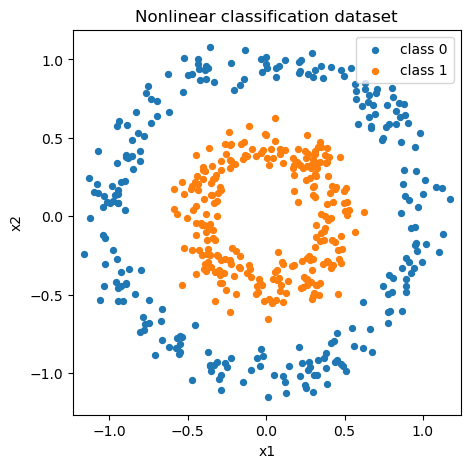

In [2]:
def make_circles(n=400, noise=0.08, factor=0.45, seed=42):
    rng = np.random.default_rng(seed)
    n_outer = n // 2
    n_inner = n - n_outer

    theta_outer = rng.uniform(0, 2*np.pi, n_outer)
    theta_inner = rng.uniform(0, 2*np.pi, n_inner)

    outer = np.column_stack([np.cos(theta_outer), np.sin(theta_outer)])
    inner = factor * np.column_stack([np.cos(theta_inner), np.sin(theta_inner)])

    X = np.vstack([outer, inner])
    y = np.concatenate([np.zeros(n_outer), np.ones(n_inner)])

    X += noise * rng.normal(size=X.shape)
    return X, y.astype(int)

X, y = make_circles(n=500, noise=0.08, factor=0.45, seed=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=18, label="class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=18, label="class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Nonlinear classification dataset")
plt.legend()
plt.axis("equal")
plt.show()

## 2. Define the neural network

We now implement a simple **2-layer multilayer perceptron (MLP)**.
It will have:

- an input layer `X` 
- one hidden layer with `tanh`
- one output layer with `sigmoid`
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

The forward pass proceeds as
\begin{align}
\bf{Z_1} &= W_1 \bf{X} + b_1 & \text{(first layer)} \\
\bf{A_1} &= \tanh(\bf{Z_1}) & \text{(fidden activation)}\\
\bf{Z_2} &= W_2 \bf{A_1} + b_2 &  \text{(output layer)}\\
\hat{\bf{Y}} &= \sigma(\bf{Z_2}) &  \text{(prediction)}\\
\end{align}

The neural net will be trained to minimize the binary cross-entropy loss, i.e.,
$$ L = -\frac{1}{m}\sum_{i=1}^m \left[y_i \log \hat y_i + (1-y_i)\log(1-\hat y_i)\right] $$
via analytical backpropagation and basic gradient descent updates.

The final sigmoid output is interpreted as the probability of class 1. 
We convert the output probabilities into class labels as
$$
\hat y_i^{\mathrm{class}} =
\begin{cases}
1, & \hat y_i \ge 0.5 \\
0, & \hat y_i < 0.5
\end{cases}
$$
and compute the `accuracy` of the classification as
$$
\mathrm{accuracy} = \frac{1}{m}\sum_{i=1}^m \mathbf{1}(\hat y_i^{\mathrm{class}} = y_i)
$$




In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def accuracy(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return np.mean(y_pred == y_true)

def init_params(input_dim=2, hidden_dim=16, seed=42):
    rng = np.random.default_rng(seed)
    return {
        "W1": 0.5 * rng.normal(size=(input_dim, hidden_dim)),
        "b1": np.zeros(hidden_dim),
        "W2": 0.5 * rng.normal(size=(hidden_dim, 1)),
        "b2": np.zeros(1),
    }

def forward(X, params):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    Y_prob = sigmoid(Z2).ravel()

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "Y_prob": Y_prob}
    return Y_prob, cache

def backward(y_true, params, cache):
    X = cache["X"]
    A1 = cache["A1"]
    Y_prob = cache["Y_prob"]
    W2 = params["W2"]

    m = X.shape[0]

    dZ2 = (Y_prob - y_true).reshape(-1, 1) / m
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (1 - A1**2)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

def update(params, grads, lr=0.1):
    for k in params:
        params[k] = params[k] - lr * grads[k]
    return params

## 3. Train the network

We now trains the two-layer neural network using **full-batch gradient descent**.
The code below trains the network:
- with 16 hidden units
- learning rate 0.1
- for 3000 gradient descent steps


In [4]:
def train_nn(X, y, hidden_dim=16, lr=0.1, steps=3000, seed=42, print_every=500):
    params = init_params(input_dim=X.shape[1], hidden_dim=hidden_dim, seed=seed)
    hist = {"loss": [], "acc": []}

    for step in range(steps):
        y_prob, cache = forward(X, params)
        loss = binary_cross_entropy(y, y_prob)
        acc = accuracy(y, y_prob)

        grads = backward(y, params, cache)
        params = update(params, grads, lr=lr)

        hist["loss"].append(loss)
        hist["acc"].append(acc)

        if step % print_every == 0 or step == steps :
            print(f"step={step:4d}   loss={loss:.4f}   acc={acc:.4f}")

    return params, hist

params, hist = train_nn(X, y, hidden_dim=16, lr=0.1, steps=3000, seed=42, print_every=500)

step=   0   loss=0.7073   acc=0.5140
step= 500   loss=0.5767   acc=0.8300
step=1000   loss=0.2858   acc=0.9940
step=1500   loss=0.1300   acc=1.0000
step=2000   loss=0.0800   acc=1.0000
step=2500   loss=0.0575   acc=1.0000


## 4. Visualize the result

Now we visualizes both the **trained classifier** and the **training history**.

In the figure below, we show:
- Left: the neural network output value at each point on the $(x_1,x_2)$ plane, as well as the decision boundary.
- Right: output accuracy and (binary cross-entropy) loss versus train step.


/tmp/ipykernel_3145421/819116452.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


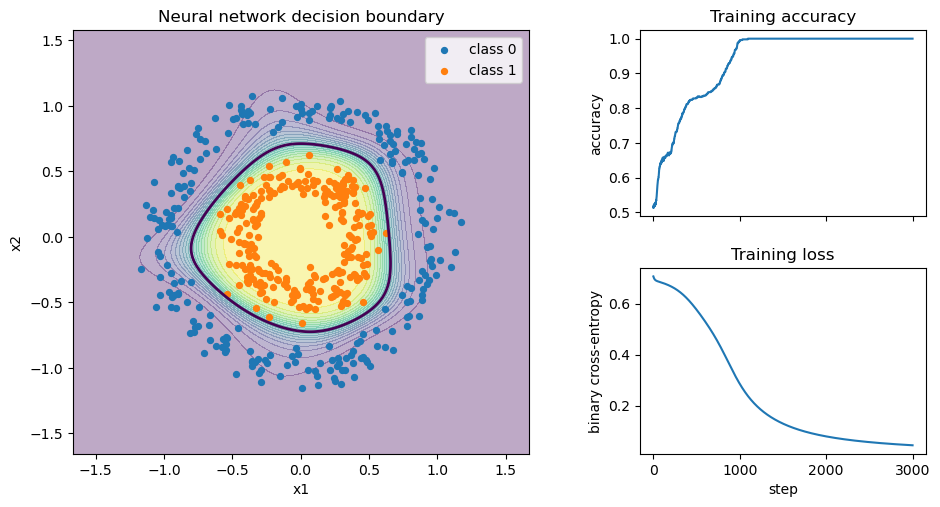

Final loss:     0.04518380996120061
Final accuracy: 1.0


In [5]:
def plot_nn_results(X, y, params, hist):
    fig = plt.figure(figsize=(11, 5.5))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.6, 1], hspace=0.28, wspace=0.3)

    ax_left = fig.add_subplot(gs[:, 0])
    ax_top = fig.add_subplot(gs[0, 1])
    ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_top)

    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 250),
        np.linspace(x2_min, x2_max, 250),
    )
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    y_prob_grid, _ = forward(grid, params)
    prob = y_prob_grid.reshape(xx1.shape)

    ax_left.contourf(xx1, xx2, prob, levels=np.linspace(0, 1, 21), alpha=0.35)
    ax_left.contour(xx1, xx2, prob, levels=[0.5], linewidths=2)

    ax_left.scatter(X[y == 0, 0], X[y == 0, 1], s=18, label="class 0")
    ax_left.scatter(X[y == 1, 0], X[y == 1, 1], s=18, label="class 1")
    ax_left.set_xlabel("x1")
    ax_left.set_ylabel("x2")
    ax_left.set_title("Neural network decision boundary")
    ax_left.legend()
    #ax_left.axis("equal")

    ax_top.plot(hist["acc"])
    ax_top.set_ylabel("accuracy")
    ax_top.set_title("Training accuracy")
    ax_top.tick_params(labelbottom=False)

    ax_bottom.plot(hist["loss"])
    ax_bottom.set_xlabel("step")
    ax_bottom.set_ylabel("binary cross-entropy")
    ax_bottom.set_title("Training loss")

    plt.tight_layout()
    plt.show()

plot_nn_results(X, y, params, hist)

y_prob, _ = forward(X, params)

print("Final loss:    ", binary_cross_entropy(y, y_prob))
print("Final accuracy:", accuracy(y, y_prob))

## 6. Another Example

We now try a different example, consisting two sinusoidal curves. 

This code below generates the new data, then trains the neural net.

step=   0   loss=0.8716   acc=0.3391
step= 500   loss=0.4965   acc=0.7904
step=1000   loss=0.4622   acc=0.8037
step=1500   loss=0.4327   acc=0.8224
step=2000   loss=0.4060   acc=0.8451
step=2500   loss=0.3822   acc=0.8611
step=3000   loss=0.3605   acc=0.8838
step=3500   loss=0.3394   acc=0.8999
step=4000   loss=0.3185   acc=0.9105
step=4500   loss=0.2983   acc=0.9226
step=5000   loss=0.2796   acc=0.9319
step=5500   loss=0.2624   acc=0.9346
step=6000   loss=0.2459   acc=0.9386
step=6500   loss=0.2297   acc=0.9399
step=7000   loss=0.2141   acc=0.9426
step=7500   loss=0.1991   acc=0.9453
step=8000   loss=0.1847   acc=0.9479
step=8500   loss=0.1710   acc=0.9519
step=9000   loss=0.1581   acc=0.9573
step=9500   loss=0.1461   acc=0.9599
step=10000   loss=0.1350   acc=0.9640
step=10500   loss=0.1248   acc=0.9666
step=11000   loss=0.1155   acc=0.9680
step=11500   loss=0.1071   acc=0.9746


/tmp/ipykernel_3145421/819116452.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


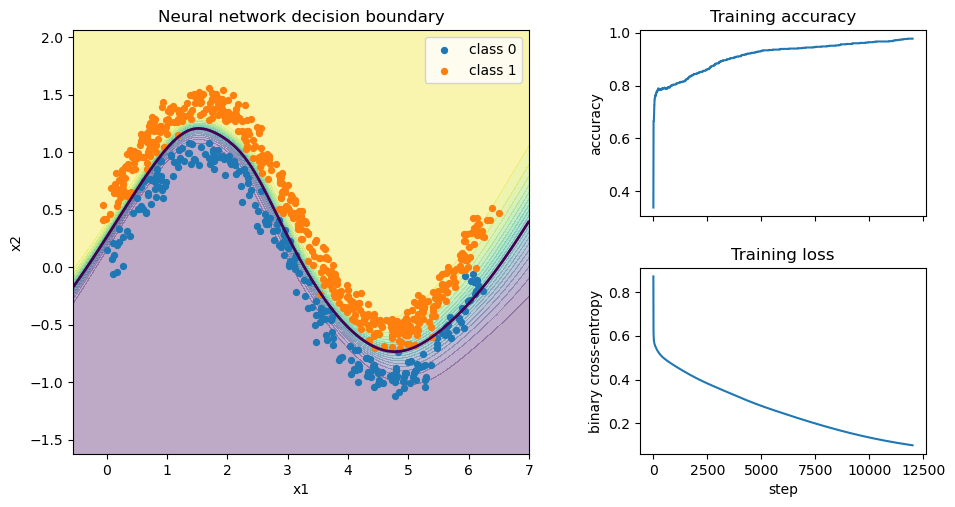

In [6]:
def make_sinusoidal(n=400, noise=0.08, shift=0.45, seed=42):
    rng = np.random.default_rng(seed)
    n_1 = n // 2
    n_2 = n - 1

    phi_1 = rng.uniform(0, 2*np.pi, n_1)
    phi_2 = rng.uniform(0, 2*np.pi, n_2)

    curve_1 = np.column_stack([phi_1, np.sin(phi_1)])
    curve_2 = np.column_stack([phi_2, np.sin(phi_2)+shift])

    X = np.vstack([curve_1, curve_2])
    y = np.concatenate([np.zeros(n_1), np.ones(n_2)])

    X += noise * rng.normal(size=X.shape)
    return X, y.astype(int)

X, y = make_sinusoidal(n=500, noise=0.08, shift=0.45, seed=42)

params, hist = train_nn(X, y, hidden_dim=32, lr=0.05, steps=12000, seed=42, print_every=500)
plot_nn_results(X, y, params, hist)

y_prob, _ = forward(X, params)